In [5]:
# ── Cell 1: Load, Filter, Prepare ─────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
)

df_raw = pd.read_csv("spatial_seer_all_rooms_v3.csv")

# Exclude rescan_num=2 entirely
#df_raw = df_raw[df_raw["rescan_num"] != 2].reset_index(drop=True)

# ── Identify qualifying TEST locations ────────────────────────────────────────
# Must have >=6 scans at rescan_num=0 AND >=2 scans at rescan_num=1
scan_counts = (
    df_raw.drop_duplicates("scan_id")
    .groupby(["location", "rescan_num"])
    .size()
    .rename("n_scans")
    .reset_index()
)
has_baseline = set(
    scan_counts[(scan_counts["rescan_num"] == 0) & (scan_counts["n_scans"] >= 6)]["location"]
)
has_rescan = set(
    scan_counts[(scan_counts["rescan_num"] == 1) & (scan_counts["n_scans"] >= 2)]["location"]
)
qualifying_locs = sorted(has_baseline & has_rescan)

print(f"Qualifying test locations ({len(qualifying_locs)}):")
for loc in qualifying_locs:
    print(f"  {loc:<35} room_type={df_raw[df_raw['location']==loc].iloc[0]['room_label']}")

# ── Encoders fit on ALL locations (train + test) ─────────────────────────────
all_locations = sorted(df_raw["location"].unique())
loc_enc     = LabelEncoder().fit(all_locations)
room_enc    = LabelEncoder().fit(df_raw["room_label"].unique())
loc_to_room = df_raw.drop_duplicates("location").set_index("location")["room_label"].to_dict()

CHANNELS = [
    "GpuUtil", "CpuUtil", "FrameTimeStdDev", "WorstFrameMs",
    "MainThreadMs", "TotalUsedMem", "CpuClockFreq",
]

# ── Series length from ALL data ──────────────────────────────────────────────
SERIES_LEN = df_raw.groupby("scan_id").size().min()


def build_scan_array(data: pd.DataFrame):
    records = []
    for scan_id, group in data.groupby("scan_id"):
        group = group.sort_values("Timestamp").iloc[:SERIES_LEN]
        records.append({
            "location": group.iloc[0]["location"],
            "ts":       group[CHANNELS].values.T,
        })
    X    = np.stack([r["ts"] for r in records])
    locs = [r["location"] for r in records]
    return X, locs


def style_cm(disp, ax, title):
    ax.set_title(title, fontsize=13, fontweight="bold", pad=15)
    ax.set_xlabel("Predicted", fontsize=12)
    ax.set_ylabel("True", fontsize=12)
    ax.tick_params(axis="both", labelsize=11)
    images = ax.get_images()
    norm   = images[0].norm
    cmap_  = images[0].get_cmap()
    for i, row in enumerate(disp.text_):
        for j, text in enumerate(row):
            val = disp.confusion_matrix[i, j]
            if val == 0:
                ax.add_patch(plt.Rectangle((j-0.5, i-0.5), 1, 1, color="white", zorder=2))
                text.set_color("black")
            else:
                r, g, b, _ = cmap_(norm(val))
                text.set_color("white" if 0.299*r + 0.587*g + 0.114*b < 0.5 else "black")
            text.set_fontsize(14)
            text.set_fontweight("bold")
            text.set_zorder(3)


# ── Train: ALL locations at rescan_num=0 ──────────────────────────────────────
# ── Test: only qualifying locations at rescan_num=1 ───────────────────────────
train_df = df_raw[df_raw["rescan_num"] == 0].reset_index(drop=True)
test_df  = df_raw[
    (df_raw["rescan"] == True) &
    (df_raw["rescan_num"] == 1) &
    (df_raw["location"].isin(qualifying_locs))
].reset_index(drop=True)

X_train, train_locs = build_scan_array(train_df)
X_test,  test_locs  = build_scan_array(test_df)

y_train_loc  = loc_enc.transform(train_locs)
y_test_loc   = loc_enc.transform(test_locs)
y_train_room = room_enc.transform([loc_to_room[l] for l in train_locs])
y_test_room  = room_enc.transform([loc_to_room[l] for l in test_locs])

print(f"\nAll locations in training : {train_df['location'].nunique()}")
print(f"Qualifying test locations: {test_df['location'].nunique()}")
print(f"Train scans : {len(X_train)}")
print(f"Test scans  : {len(X_test)}")
print(f"Series len  : {SERIES_LEN}")
print(f"X_train     : {X_train.shape}")
print(f"X_test      : {X_test.shape}")
print("\nCell 1 complete.")

Qualifying test locations (17):
  3215                                room_type=lab
  3310                                room_type=conference
  4001                                room_type=conference
  4211                                room_type=conference
  4213                                room_type=lab
  4214                                room_type=lab
  4218                                room_type=conference
  4307                                room_type=conference
  CEEDKitchen                         room_type=kitchen
  Floor2Kitchen                       room_type=kitchen
  Floor3Kitchen                       room_type=kitchen
  Floor4HallwayInFrontOf4214          room_type=hallway
  Floor4Kitchen                       room_type=kitchen
  InFrontOfCEEDHallway                room_type=hallway
  Outside3102                         room_type=hallway
  Outside3410                         room_type=hallway
  privateeyelab                       room_type=lab

All locations in

Location accuracy : 21.4%  (9/42)
Room type accuracy: 76.2%  (32/42)



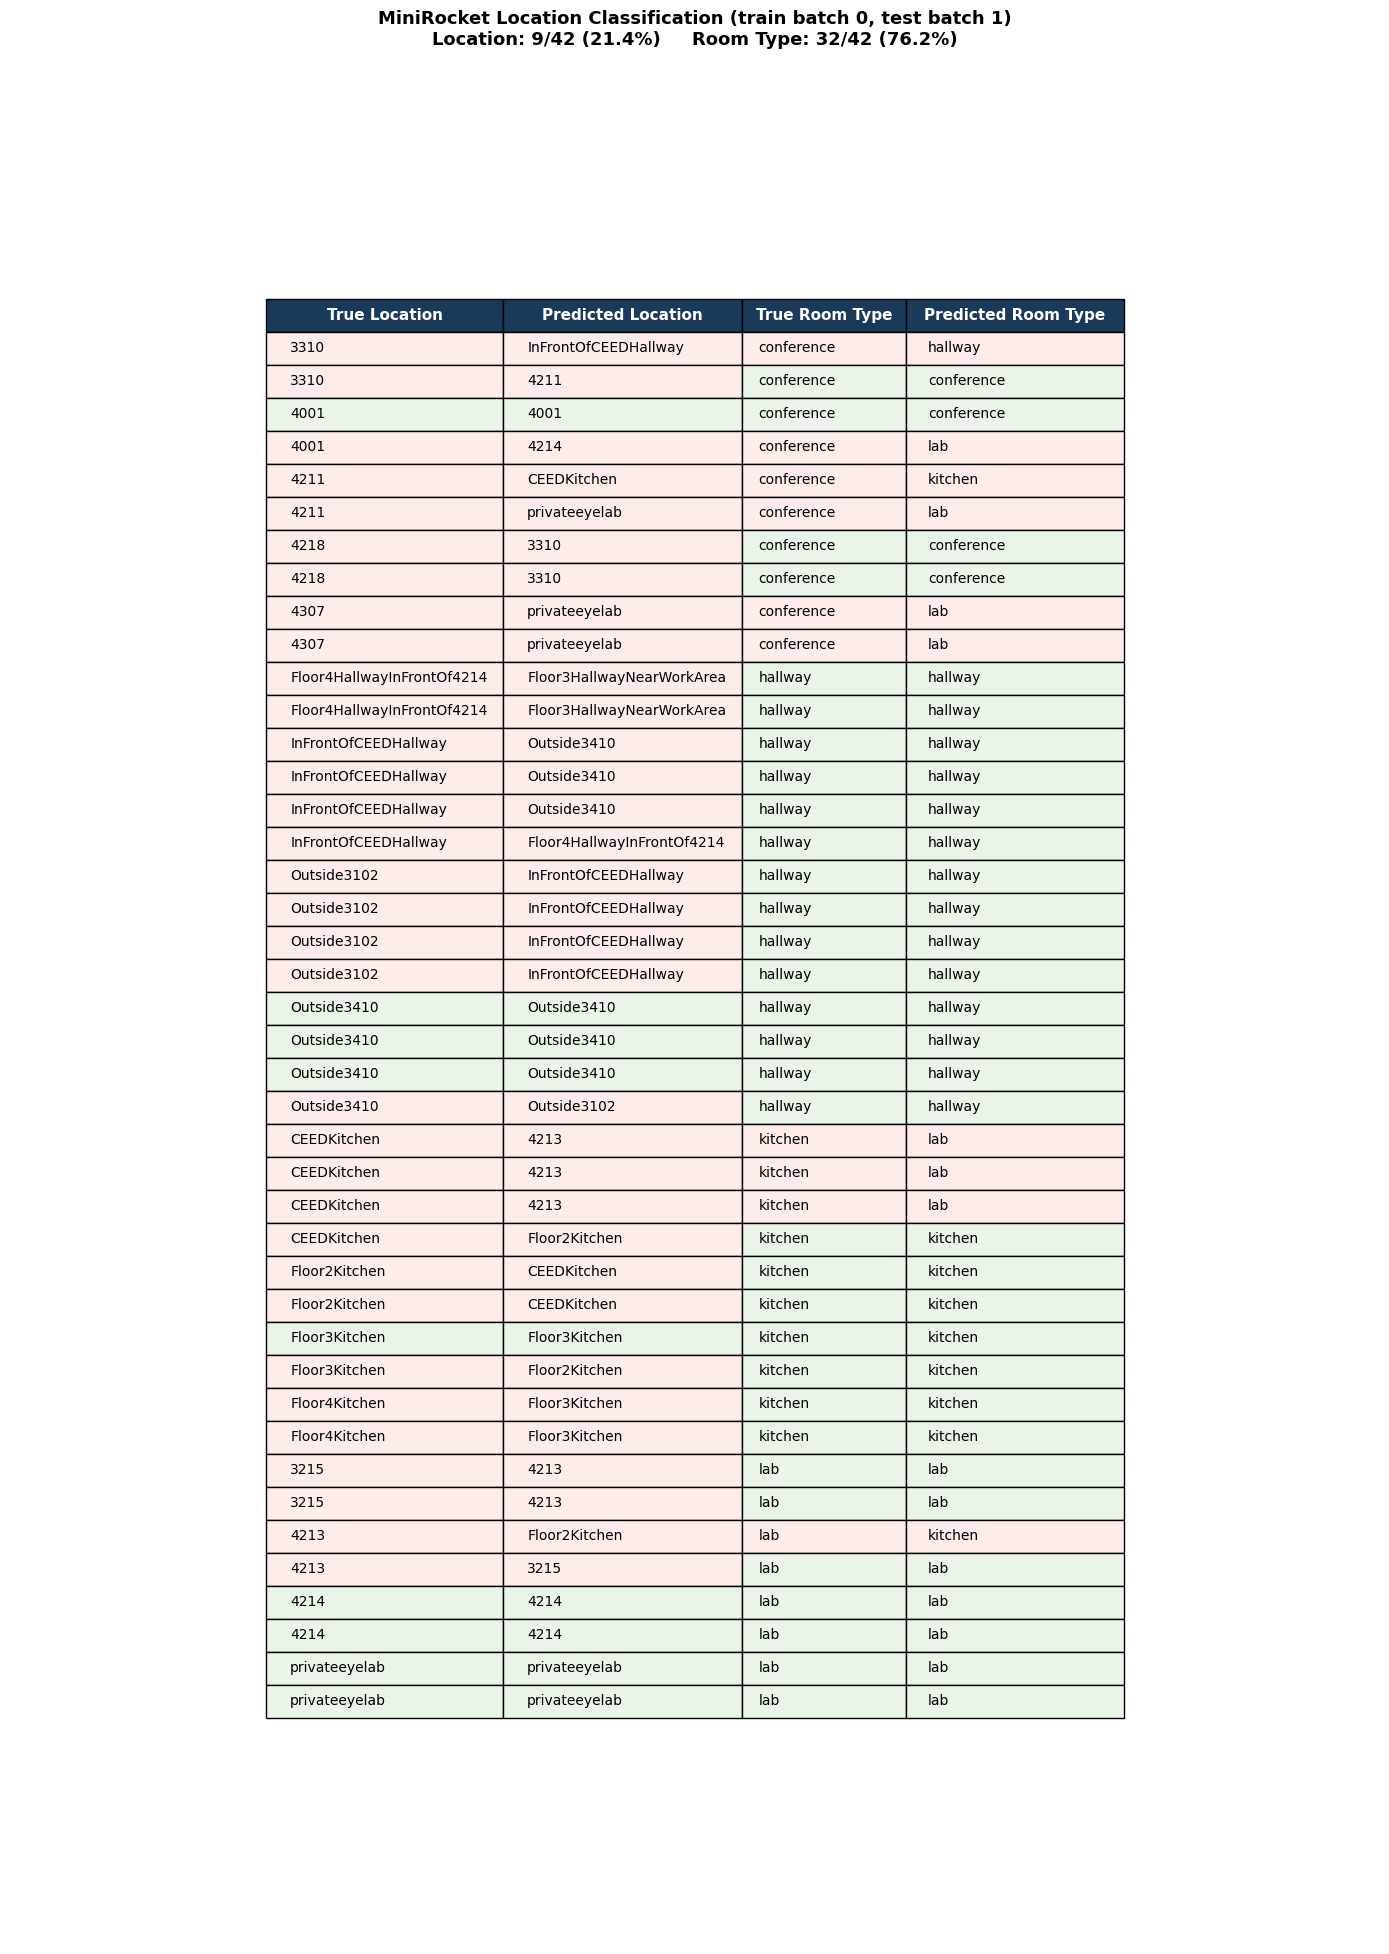

In [6]:
# ── Cell 2: MiniRocket Location Classification + Results Table ────────────────
from aeon.classification.convolution_based import MiniRocketClassifier

clf = MiniRocketClassifier(random_state=42)
clf.fit(X_train, y_train_loc)
y_pred_loc = clf.predict(X_test)

pred_locs  = loc_enc.inverse_transform(y_pred_loc)
true_locs  = loc_enc.inverse_transform(y_test_loc)
pred_rooms = [loc_to_room[l] for l in pred_locs]
true_rooms = [loc_to_room[l] for l in true_locs]

loc_acc  = accuracy_score(y_test_loc, y_pred_loc)
room_acc = sum(t == p for t, p in zip(true_rooms, pred_rooms)) / len(true_rooms)

print(f"Location accuracy : {loc_acc:.1%}  ({sum(y_test_loc == y_pred_loc)}/{len(y_test_loc)})")
print(f"Room type accuracy: {room_acc:.1%}  ({sum(t==p for t,p in zip(true_rooms, pred_rooms))}/{len(true_rooms)})\n")

# ── Results table ─────────────────────────────────────────────────────────────
GREEN_BG  = "#eaf4e8"
RED_BG    = "#fdecea"
HEADER_BG = "#1a3a5c"

scan_results = pd.DataFrame({
    "true_location": true_locs,
    "pred_location": pred_locs,
    "true_room":     true_rooms,
    "pred_room":     pred_rooms,
})
scan_results["loc_correct"]  = scan_results["true_location"] == scan_results["pred_location"]
scan_results["room_correct"] = scan_results["true_room"] == scan_results["pred_room"]

fig, ax = plt.subplots(figsize=(14, len(scan_results) * 0.42 + 2))
ax.axis("off")

cell_text = [
    [r["true_location"], r["pred_location"], r["true_room"], r["pred_room"]]
    for _, r in scan_results.iterrows()
]

table = ax.table(
    cellText=cell_text,
    colLabels=["True Location", "Predicted Location", "True Room Type", "Predicted Room Type"],
    loc="center",
    cellLoc="left",
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.6)

for j in range(4):
    table[0, j].set_facecolor(HEADER_BG)
    table[0, j].set_text_props(color="white", fontweight="bold", fontsize=11)

for i, row in scan_results.iterrows():
    for j in range(2):
        table[i + 1, j].set_facecolor(GREEN_BG if row["loc_correct"] else RED_BG)
    for j in range(2, 4):
        table[i + 1, j].set_facecolor(GREEN_BG if row["room_correct"] else RED_BG)

table.auto_set_column_width(list(range(4)))
n = len(scan_results)
ax.set_title(
    f"MiniRocket Location Classification (train batch 0, test batch 1)\n"
    f"Location: {scan_results['loc_correct'].sum()}/{n} ({loc_acc:.1%})     "
    f"Room Type: {scan_results['room_correct'].sum()}/{n} ({room_acc:.1%})",
    fontsize=13, fontweight="bold", pad=20,
)
plt.tight_layout()
plt.show()

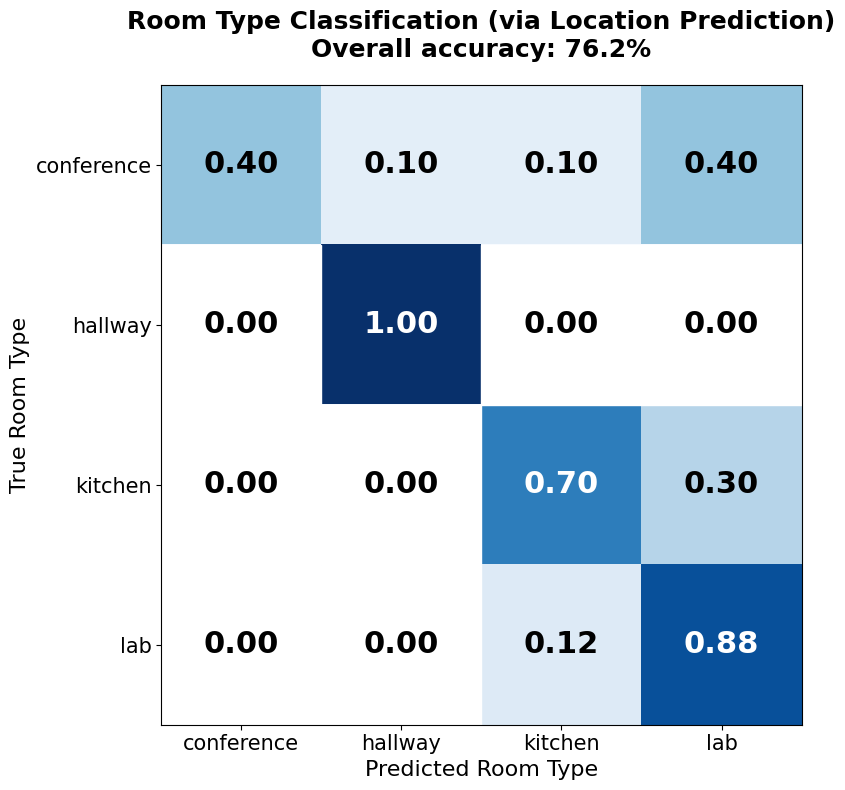

In [7]:
# ── Cell 3: Room Type Confusion Matrix (derived from location predictions) ────
y_true_room_encoded = room_enc.transform(true_rooms)
y_pred_room_encoded = room_enc.transform(pred_rooms)

cm = confusion_matrix(y_true_room_encoded, y_pred_room_encoded, normalize="true")

fig, ax = plt.subplots(figsize=(9, 8))
disp = ConfusionMatrixDisplay(cm, display_labels=room_enc.classes_)
disp.plot(ax=ax, colorbar=False, cmap="Blues", values_format=".2f")

ax.set_title(
    f"Room Type Classification (via Location Prediction)\n"
    f"Overall accuracy: {room_acc:.1%}",
    fontsize=18, fontweight="bold", pad=20,
)
ax.set_xlabel("Predicted Room Type", fontsize=16)
ax.set_ylabel("True Room Type", fontsize=16)
ax.tick_params(axis="both", labelsize=15)

images = ax.get_images()
norm_  = images[0].norm
cmap_  = images[0].get_cmap()
for i, row in enumerate(disp.text_):
    for j, text in enumerate(row):
        val = cm[i, j]
        if val == 0:
            ax.add_patch(plt.Rectangle((j-0.5, i-0.5), 1, 1, color="white", zorder=2))
            text.set_color("black")
        else:
            r, g, b, _ = cmap_(norm_(val))
            text.set_color("white" if 0.299*r + 0.587*g + 0.114*b < 0.5 else "black")
        text.set_fontsize(22)
        text.set_fontweight("bold")
        text.set_zorder(3)

plt.tight_layout()
plt.show()

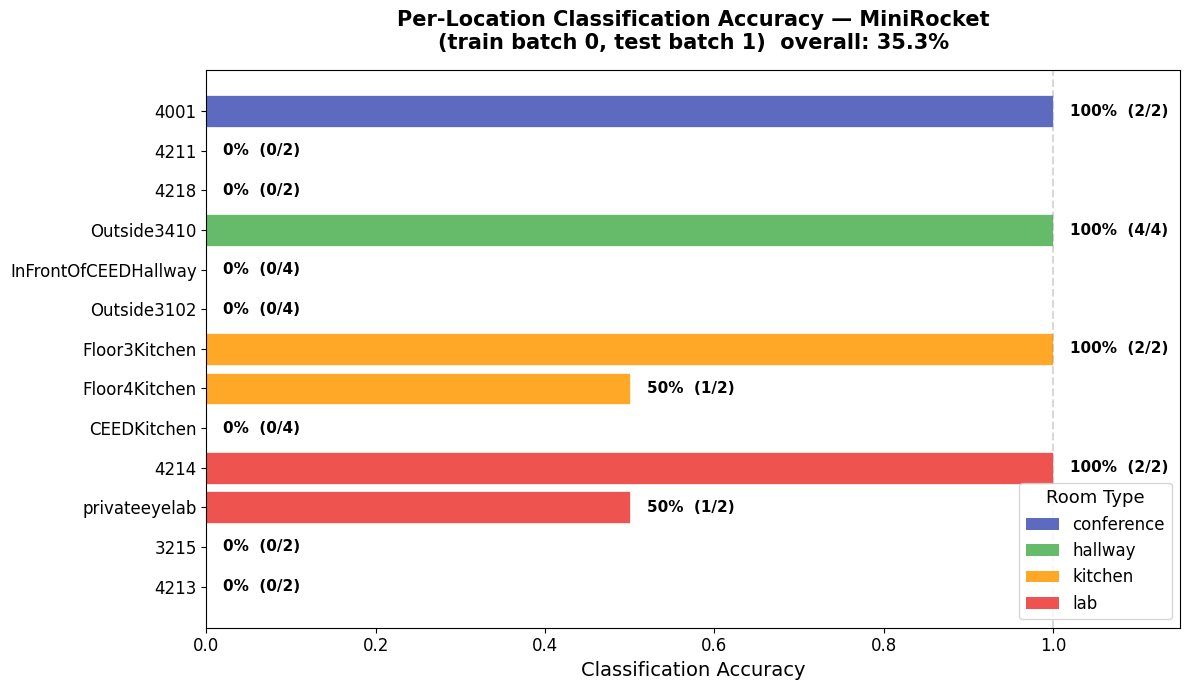

In [25]:
# ── Cell 4: Per-Location Accuracy Bar Chart ───────────────────────────────────

# Compute per-location accuracy
loc_accuracy = (
    scan_results.groupby("true_location")
    .agg(
        correct=("loc_correct", "sum"),
        total=("loc_correct", "count"),
        room_type=("true_room", "first"),
    )
    .reset_index()
)
loc_accuracy["accuracy"] = loc_accuracy["correct"] / loc_accuracy["total"]
loc_accuracy = loc_accuracy.sort_values(["room_type", "accuracy"], ascending=[True, False])

# Color by room type
room_colors = {
    "conference": "#5c6bc0",
    "hallway":    "#66bb6a",
    "kitchen":    "#ffa726",
    "lab":        "#ef5350",
}

fig, ax = plt.subplots(figsize=(12, 7))

bars = ax.barh(
    range(len(loc_accuracy)),
    loc_accuracy["accuracy"],
    color=[room_colors[r] for r in loc_accuracy["room_type"]],
    edgecolor="white",
    linewidth=0.5,
)

ax.set_yticks(range(len(loc_accuracy)))
ax.set_yticklabels(loc_accuracy["true_location"], fontsize=12)
ax.set_xlabel("Classification Accuracy", fontsize=14)
ax.set_title(
    f"Per-Location Classification Accuracy — MiniRocket\n"
    f"(train batch 0, test batch 1)  overall: {loc_acc:.1%}",
    fontsize=15, fontweight="bold", pad=15,
)
ax.set_xlim(0, 1.15)
ax.axvline(x=1.0, color="gray", linestyle="--", alpha=0.3)
ax.tick_params(axis="x", labelsize=12)

# Add accuracy labels on bars
for i, (_, row) in enumerate(loc_accuracy.iterrows()):
    ax.text(
        row["accuracy"] + 0.02, i,
        f"{row['accuracy']:.0%}  ({int(row['correct'])}/{int(row['total'])})",
        va="center", fontsize=11, fontweight="bold",
    )

# Legend
from matplotlib.patches import Patch
legend_patches = [Patch(facecolor=c, label=r) for r, c in room_colors.items()]
ax.legend(handles=legend_patches, loc="lower right", fontsize=12, title="Room Type", title_fontsize=13)

ax.invert_yaxis()
plt.tight_layout()
plt.show()

  3211                                room=conference   acc=1.0000  (n=2)
  3215                                room=lab          acc=0.6250  (n=8)
  3310                                room=conference   acc=0.8750  (n=8)
  4001                                room=conference   acc=0.3333  (n=12)
  4211                                room=conference   acc=0.6250  (n=8)
  4213                                room=lab          acc=0.2500  (n=8)
  4214                                room=lab          acc=0.0000  (n=8)
  4218                                room=conference   acc=0.2500  (n=8)
  4307                                room=conference   acc=0.6250  (n=8)
  CEEDKitchen                         room=kitchen      acc=0.8000  (n=10)
  Floor2Kitchen                       room=kitchen      acc=0.6250  (n=8)
  Floor3HallwayNearWorkArea           room=hallway      acc=1.0000  (n=2)
  Floor3Kitchen                       room=kitchen      acc=0.7500  (n=12)
  Floor4HallwayInFrontOf4214       

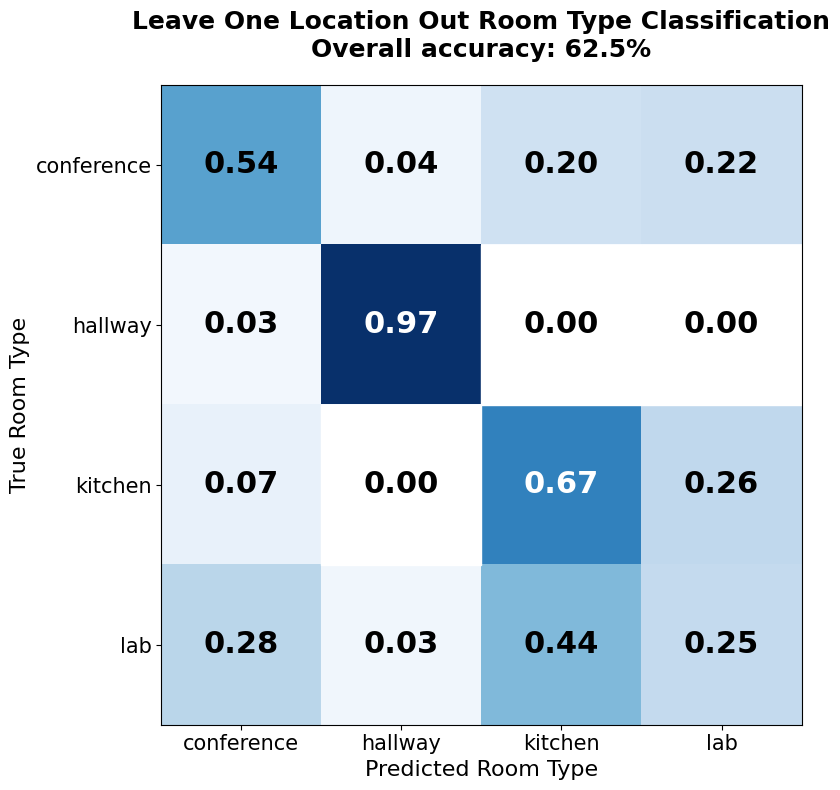

In [8]:
# ── Cell 5: LOLO Room Type Classification ─────────────────────────────────────
from sklearn.model_selection import LeaveOneGroupOut

X_all, all_locs = build_scan_array(df_raw)
y_room_all_lolo = room_enc.transform([loc_to_room[l] for l in all_locs])
locations_lolo  = np.array(all_locs)

logo = LeaveOneGroupOut()
y_true_all, y_pred_all, fold_results = [], [], []

for train_idx, test_idx in logo.split(X_all, y_room_all_lolo, locations_lolo):
    X_tr, X_te = X_all[train_idx], X_all[test_idx]
    y_tr, y_te = y_room_all_lolo[train_idx], y_room_all_lolo[test_idx]
    held_out   = locations_lolo[test_idx][0]

    clf = MiniRocketClassifier(random_state=42)
    clf.fit(X_tr, y_tr)
    y_pred = clf.predict(X_te)

    acc = accuracy_score(y_te, y_pred)
    fold_results.append({
        "held_out":  held_out,
        "room_type": loc_to_room[held_out],
        "accuracy":  acc,
        "n_test":    len(y_te),
    })
    y_true_all.extend(y_te)
    y_pred_all.extend(y_pred)
    print(f"  {held_out:<35} room={loc_to_room[held_out]:<12} acc={acc:.4f}  (n={len(y_te)})")

results_df_lolo = pd.DataFrame(fold_results)
overall_acc = accuracy_score(y_true_all, y_pred_all)

print(f"\n{'='*60}")
print(f"LOLO mean accuracy (per-fold avg) : {results_df_lolo['accuracy'].mean():.4f} ± {results_df_lolo['accuracy'].std():.4f}")
print(f"LOLO overall accuracy (all scans) : {overall_acc:.4f}")
print(f"{'='*60}\n")

print("Per-room-type breakdown:")
print(results_df_lolo.groupby("room_type")["accuracy"].agg(["mean", "std", "count"]).round(4))

print("\nClassification Report:")
print(classification_report(y_true_all, y_pred_all, target_names=room_enc.classes_, zero_division=0))

# ── Normalized confusion matrix ───────────────────────────────────────────────
cm = confusion_matrix(y_true_all, y_pred_all, normalize="true")

fig, ax = plt.subplots(figsize=(9, 8))
disp = ConfusionMatrixDisplay(cm, display_labels=room_enc.classes_)
disp.plot(ax=ax, colorbar=False, cmap="Blues", values_format=".2f")

ax.set_title(
    f"Leave One Location Out Room Type Classification\n"
    f"Overall accuracy: {overall_acc:.1%}",
    fontsize=18, fontweight="bold", pad=20,
)
ax.set_xlabel("Predicted Room Type", fontsize=16)
ax.set_ylabel("True Room Type", fontsize=16)
ax.tick_params(axis="both", labelsize=15)

images = ax.get_images()
norm_  = images[0].norm
cmap_  = images[0].get_cmap()
for i, row in enumerate(disp.text_):
    for j, text in enumerate(row):
        val = cm[i, j]
        if val == 0:
            ax.add_patch(plt.Rectangle((j-0.5, i-0.5), 1, 1, color="white", zorder=2))
            text.set_color("black")
        else:
            r, g, b, _ = cmap_(norm_(val))
            text.set_color("white" if 0.299*r + 0.587*g + 0.114*b < 0.5 else "black")
        text.set_fontsize(22)
        text.set_fontweight("bold")
        text.set_zorder(3)

plt.tight_layout()
plt.show()